In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv('loan_approval.xls')
print(df.head())
df=df.drop(columns=['name','city'])
print(df.isna().sum()) #`no empty features in current data set
df.head()



              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27    50.0          False  
1              28    55.0          False  
2              13    45.0          False  
3              29    50.0          False  
4               4    25.0          False  
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,False
1,44592,729,15446,28,55.0,False
2,33278,584,11189,13,45.0,False
3,127196,344,48823,29,50.0,False
4,66048,496,47174,4,25.0,False


In [3]:

x=df.drop(columns='loan_approved').to_numpy()
#df['loan_approved']=df['loan_approved'].replace{True:1,False:0}
y=df['loan_approved'].astype(int).to_numpy()

In [4]:
column=df.columns
print(column)
print("x",x[:5,:])
print("y",y[:5])
print(x[:,0])

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'],
      dtype='str')
x [[1.13810e+05 3.89000e+02 3.96980e+04 2.70000e+01 5.00000e+01]
 [4.45920e+04 7.29000e+02 1.54460e+04 2.80000e+01 5.50000e+01]
 [3.32780e+04 5.84000e+02 1.11890e+04 1.30000e+01 4.50000e+01]
 [1.27196e+05 3.44000e+02 4.88230e+04 2.90000e+01 5.00000e+01]
 [6.60480e+04 4.96000e+02 4.71740e+04 4.00000e+00 2.50000e+01]]
y [0 0 0 0 0]
[113810.  44592.  33278. ...  41957. 139022.  41188.]


In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
def zscore(x):
    mean=x.mean(axis=0)
    sigma=x.std(axis=0)
    x_norm=(x-mean)/(sigma)
    return x_norm, mean ,sigma

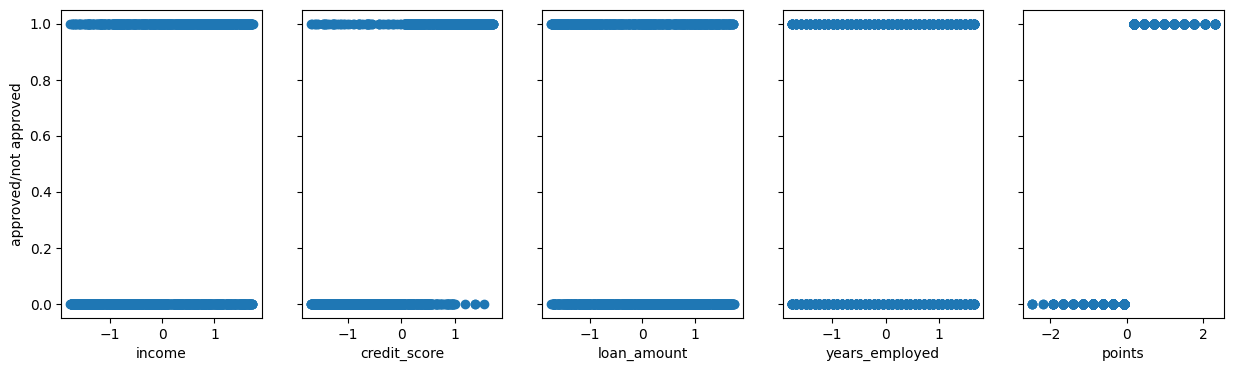

In [7]:
x_norm,mean,sigma=zscore(x_train)
fig,ax=plt.subplots(1,5,figsize=(15,4),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_norm[:,i],y_train)
    ax[i].set_xlabel(column[i])
ax[0].set_ylabel("approved/not approved")
plt.show()

In [8]:
def compute_gradient(x,y,w,b):
    m,n=x.shape
    dj_dw=np.zeros(n)
    dj_db=0
    for i in range(m):
        z=np.dot(w,x[i])+b
        f_wb=1/(1+np.exp(-z))
        err=f_wb-y[i]
        for j in range(n):
            dj_dw[j]+=err*x[i][j]
        dj_db+=err
    dj_db=dj_db/m
    dj_dw=dj_dw/m
    return dj_dw,dj_db

In [9]:
def gradient_descent(x,y,w,b,iteration,alpha):
    w_int=w
    b_int=b
    
    for i in range(iteration):
        dj_dw,dj_db=compute_gradient(x,y,w_int,b_int)
        w_int=w_int-alpha*dj_dw
        b_int=b_int-alpha*dj_db
    return w_int,b_int

In [10]:
w_intial=np.zeros(x.shape[1])
b_initial=0
alpha=0.1
iterations=9000
w,b=gradient_descent(x_norm,y_train,w_intial,b_initial,iterations,alpha)
print(w,b)

[ 0.4642688   1.33814158 -0.49828657  0.20771027 10.64921709] -0.6315863478928334


In [11]:
def out(check):

    print(check)
    z = np.dot(check, w) + b
    f_wb = 1 / (1 + np.exp(- z))
    print("f_wb=",f_wb)
    if f_wb >= 0.5:
        f_wb=1
        print(f_wb)
        print(bool(f_wb))
        
    else:
        f_wb=0
        print(f_wb)
        print(bool(f_wb))


In [12]:
print(x[1997])
check=out(x_norm[1])
print("actutal",y[1])
    

[4.1957e+04 7.6300e+02 1.6752e+04 5.0000e+00 6.0000e+01]
[-0.58084238 -0.4040078  -0.20015315 -1.31735892 -1.14503355]
f_wb= 1.0060485812859508e-06
0
False
actutal 0


In [13]:
correct = 0
x_norm_test=(x_test-mean)/sigma
for i in range(len(y_test)):
    z = np.dot(x_norm_test[i], w) + b
    p = 1/(1 + np.exp(-z))

    pred = 1 if p >= 0.5 else 0

    if pred == y_test[i]:
        correct += 1

print("Accuracy:", correct/len(y_test)*100,"%")

Accuracy: 100.0 %


In [14]:
print(column)
check=[600000,700,70000,30,50]
check_norm=(check-mean)/sigma
out(check_norm)

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'],
      dtype='str')
[14.77203908  0.78197946  3.1520366   0.8020296  -0.34964121]
f_wb= 0.8952547212486379
1
True
